In [1]:
pip install pytrends matplotlib pandas seaborn plotly

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pytrends.request import TrendReq

# setup pytrend library and keyword define

In [31]:
from pytrends.request import TrendReq
pytrend = TrendReq(hl ='en-US' , tz =360)
keyword = "artificial intelligence"

# DATA REQUEST

In [32]:
pytrend.build_payload([keyword], cat=0, timeframe='today 12-m')

# Country Data

In [33]:
region_data = pytrend.interest_by_region(resolution='COUNTRY', inc_low_vol=False)

region_data = region_data.sort_values(by=keyword, ascending=False).head(10)

# Plot Chart

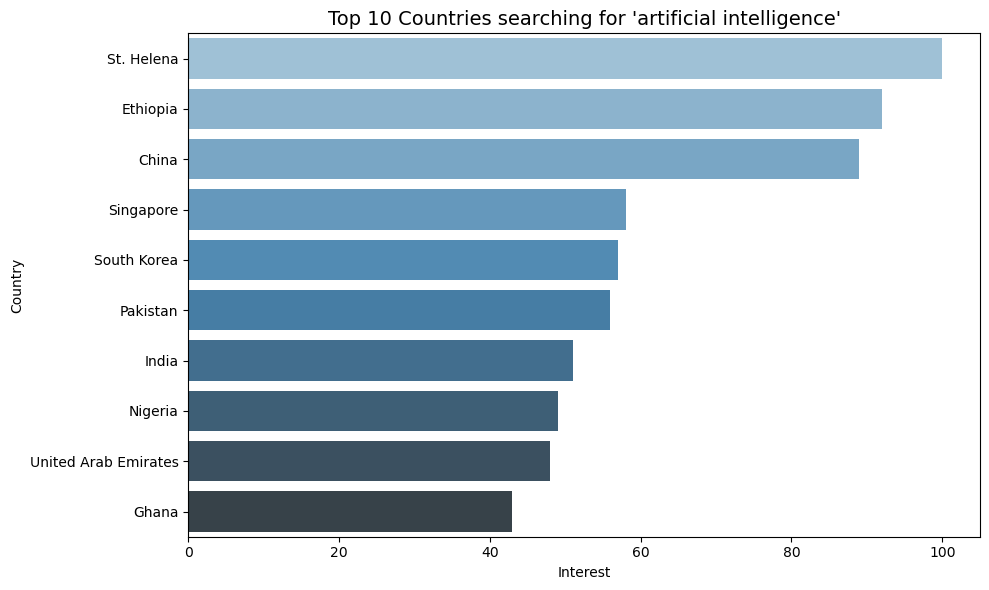

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    x=region_data[keyword],
    y=region_data.index,
    palette="Blues_d"
)

plt.title(f"Top 10 Countries searching for '{keyword}'", fontsize=14)
plt.xlabel("Interest")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [35]:
region_data = pytrend.interest_by_region(resolution='COUNTRY', inc_low_vol=False)
region_data = region_data.reset_index()

# World Map

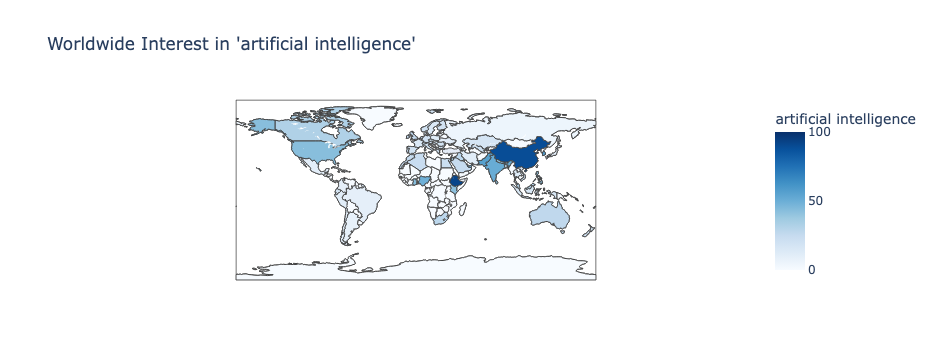

In [36]:
import plotly.express as px

fig = px.choropleth(
    region_data,
    locations="geoName",
    locationmode="country names",
    color=keyword,
    color_continuous_scale="Blues",
    title=f"Worldwide Interest in '{keyword}'"
)

fig.show()

# Time wise interest

In [37]:
pytrend.build_payload([keyword], timeframe='today 12-m')

time_df = pytrend.interest_over_time()

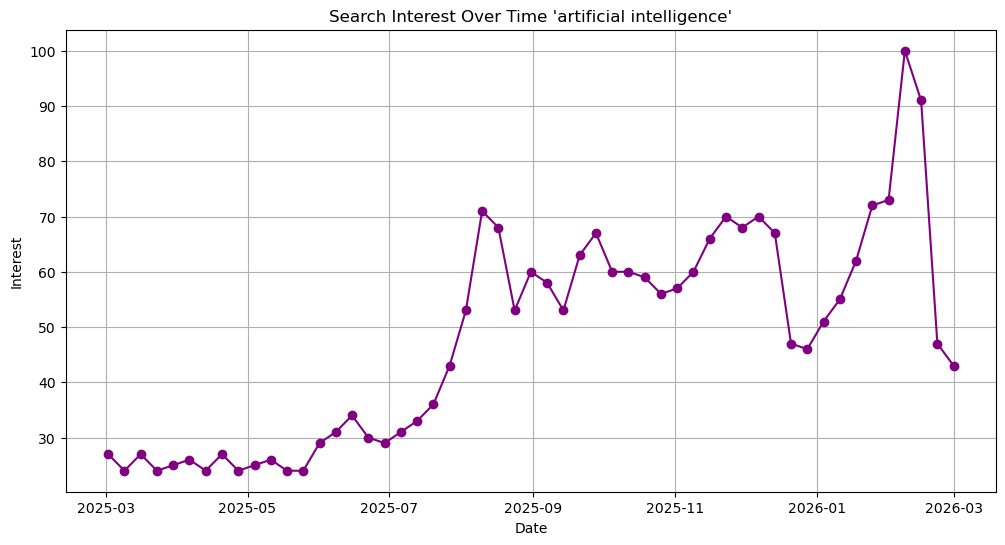

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(time_df.index, time_df[keyword], marker='o', color='purple')

plt.title(f"Search Interest Over Time '{keyword}'")
plt.xlabel("Date")
plt.ylabel("Interest")

plt.grid(True)

plt.show()

# Multiple keywords Compare

In [39]:
kw_list = ["artificial intelligence", "data science", "machine learning"]
pytrend.build_payload(kw_list, cat=0, timeframe ='today 12-m', geo='',gprop='')

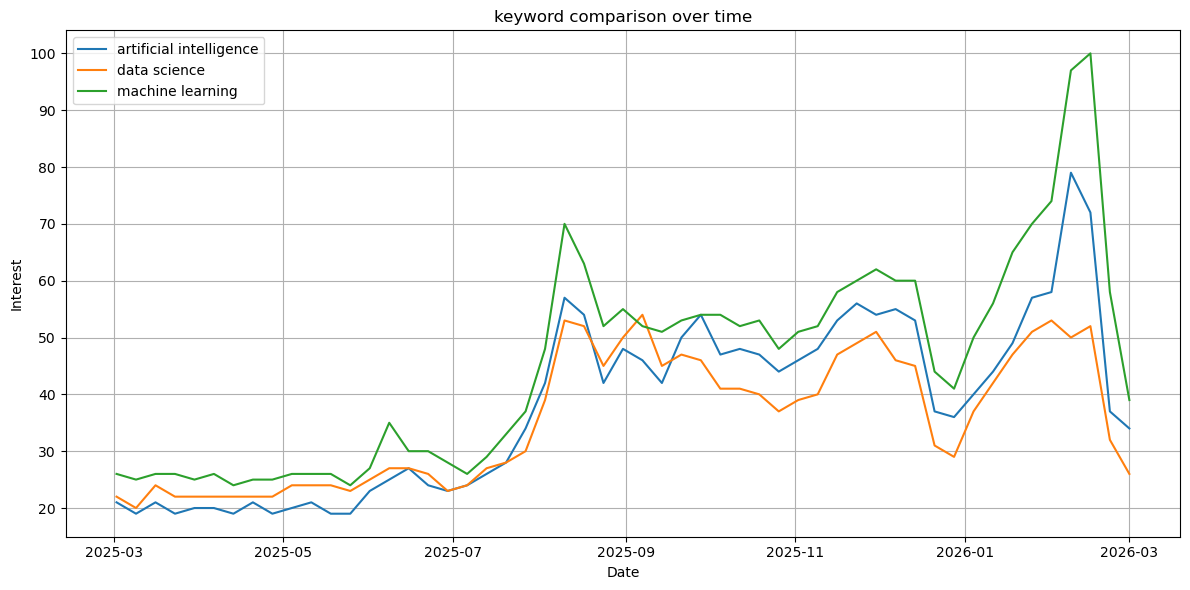

In [40]:
compare_df = pytrend.interest_over_time()

plt.figure(figsize=(12,6))
for kw in kw_list:
    plt.plot(compare_df.index,compare_df[kw],label=kw)

plt.title("keyword comparison over time")
plt.xlabel("Date")
plt.ylabel("Interest")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Related Queries Analysis

In [41]:
related_queries = pytrend.related_queries()

print(related_queries[keyword]['top'])

                                           query  value
0                                             ai    100
1                     artificial intelligence ai     99
2                   artificial intelligence news     95
3                what is artificial intelligence     47
4                 artificial intelligence review     41
5               artificial intelligence research     28
6                    artificial intelligence app     18
7             artificial intelligence technology     18
8                artificial intelligence article     17
9                                     what is ai     15
10              artificial intelligence services     15
11                artificial intelligence course     14
12               artificial intelligence meaning     14
13            artificial intelligence definition     14
14           artificial intelligence in business     12
15          artificial intelligence applications     11
16          artificial intelligence for business

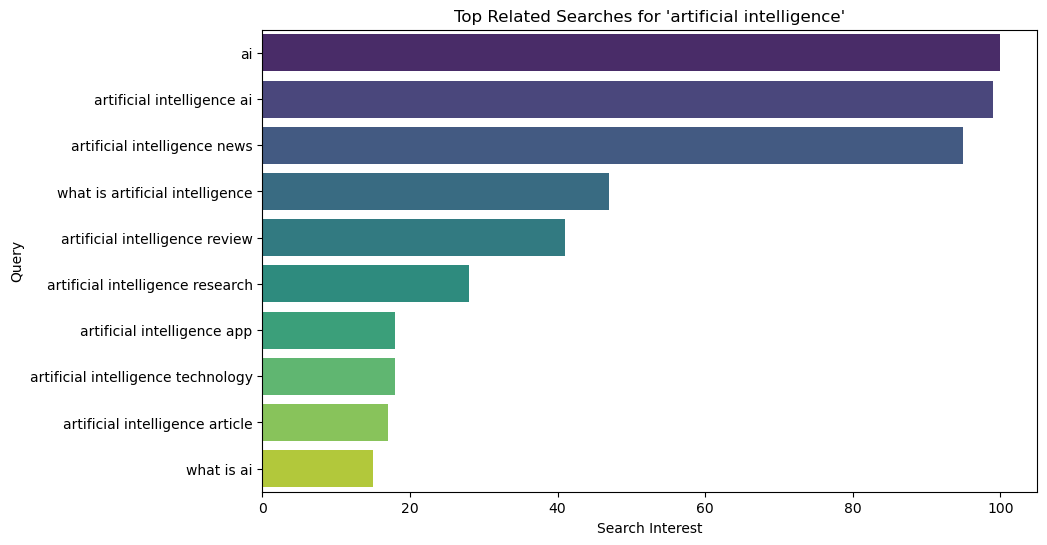

In [42]:
rq = related_queries[keyword]['top'].head(10)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(x="value", y="query", data=rq, palette="viridis")

plt.title(f"Top Related Searches for '{keyword}'")
plt.xlabel("Search Interest")
plt.ylabel("Query")

plt.show()

# Monthly Trend Analysis

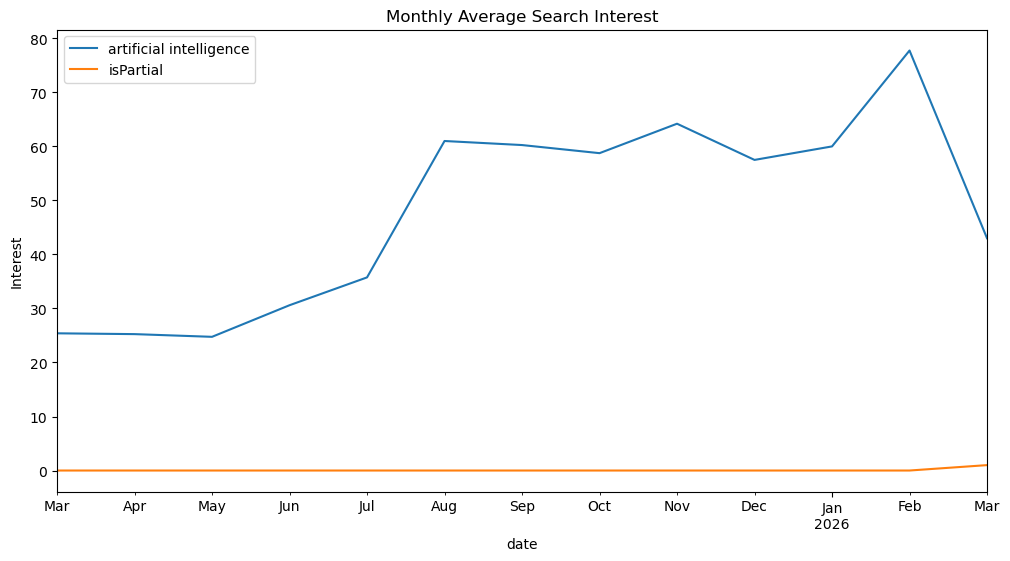

In [43]:
monthly_trend = time_df.resample('M').mean()

monthly_trend.plot(figsize=(12,6))
plt.title("Monthly Average Search Interest")
plt.ylabel("Interest")
plt.show()

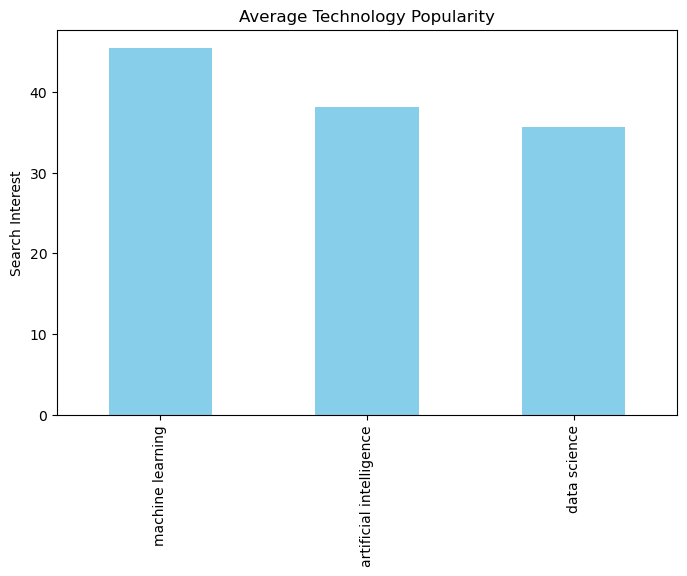

In [44]:
time_df = pytrend.interest_over_time()
time_df = time_df.drop(columns=['isPartial'])
avg_interest = time_df[kw_list].mean().sort_values(ascending=False)

import matplotlib.pyplot as plt

avg_interest.plot(kind='bar', figsize=(8,5), color="skyblue")

plt.title("Average Technology Popularity")
plt.ylabel("Search Interest")

plt.show()

# Download Data as CSV

In [45]:
time_df.to_csv("trend_data.csv")
region_data.to_csv("country_interest.csv")